In [4]:
import sys
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

from langgraph.graph import START,END,StateGraph
from server.graph.state import AuditState
from server.graph.nodes.router import router , route_after_router
from server.graph.nodes.mapper import mapper , check_mapper_success
from server.graph.nodes.attacker import attacker
from server.graph.nodes.verifier import verifier
from server.graph.nodes.reporter import reporter
from server.graph.nodes.aligner import aligner
from server.graph.nodes.assistant import assistant
from server.graph.edges import continue_to_verification
from functools import partial

from dotenv import load_dotenv
load_dotenv()
from server.core.llms import groq_reasoning , elite_accuracy_chain

from server.logger.logger import logging
from server.exception.exception import CustomException

from langgraph.checkpoint.memory import MemorySaver

Project root: c:\Users\beast\Documents\GEN_AI_Projects\multi-agent-security-auditor


In [7]:

memory = MemorySaver()
logging.info('Started Building Graph')
# Defining  workflow
workflow = StateGraph(AuditState)

# Adding nodes
workflow.add_node('router',partial(router,llm=groq_reasoning))
workflow.add_node("mapper", partial(mapper, llm=elite_accuracy_chain))
workflow.add_node("attacker", partial(attacker, llm=elite_accuracy_chain))
workflow.add_node("verifier", partial(verifier, llm=elite_accuracy_chain))
workflow.add_node("reporter", partial(reporter, llm=groq_reasoning))
workflow.add_node("aligner", partial(aligner, llm=elite_accuracy_chain))
workflow.add_node("assistant", partial(assistant, llm=groq_reasoning))

logging.info('Added nodes successfully')
# Defining Edges

workflow.add_edge(START,'router')
# Adding conditional edge to create audit report or chat 
workflow.add_conditional_edges('router',route_after_router,{'AUDIT':'mapper','CHAT':'assistant'})

# OLD: workflow.add_edge('mapper','attacker')

# NEW:
workflow.add_conditional_edges(
            "mapper",
            check_mapper_success,
            {
                "SUCCESS": "attacker",
                "INVALID_INPUT": "assistant"  # Direct bypass to the Chat Assistant
            }
        )      

workflow.add_conditional_edges('attacker',continue_to_verification,['verifier','reporter'])

workflow.add_edge('verifier','reporter')

workflow.add_edge('reporter','aligner')

workflow.add_edge('aligner',END)

# 6. CHAT PATH: Assistant responds and ends (or loops back to START)
workflow.add_edge('assistant', END)

logging.info('Added edges successfully')
# Compiling graph
graph = workflow.compile(checkpointer=memory)

logging.info('Graph compiled and returned successfully')


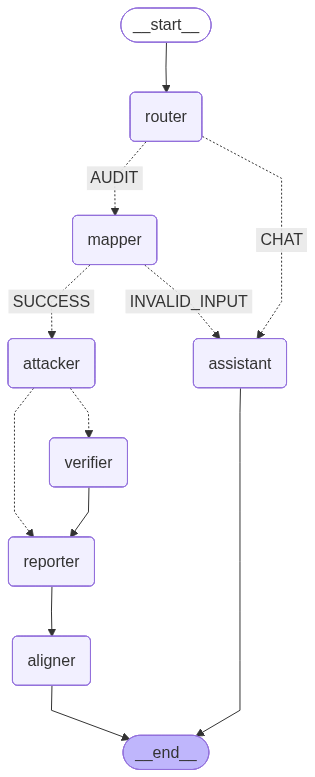

In [8]:
graph